In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

df_raw = pd.read_csv("../data/raw/athlete_sessions.csv")

SIGNALS = ["heart_rate","hrv","reaction_time_ms","decision_accuracy",
           "pupil_diameter","blink_rate","saccade_velocity",
           "cortisol_proxy","focus_score","movement_efficiency"]

COLOR_MAP = {"fatigued": "#E24B4A", "normal": "#EF9F27", "zone": "#1D9E75"}

print(f"Dataset: {len(df_raw):,} rows | "
      f"{df_raw['session_id'].nunique()} sessions | "
      f"{df_raw['athlete_id'].nunique()} athletes")
df_raw.head()

Dataset: 63,000 rows | 2100 sessions | 100 athletes


,athlete_id,session_id,reading,sport,state,state_label,heart_rate,hrv,reaction_time_ms,decision_accuracy,pupil_diameter,blink_rate,saccade_velocity,cortisol_proxy,focus_score,movement_efficiency
0,0,0,0,swimming,0,fatigued,79.104959,26.623297,343.675954,72.189869,0.447927,29.197587,181.109531,0.820615,3.144401,0.570249
1,0,0,1,swimming,0,fatigued,90.551217,30.336093,377.346869,59.664379,0.535361,20.531415,239.315400,0.720511,2.164694,0.595487
2,0,0,2,swimming,0,fatigued,90.232330,20.409285,414.053724,40.758592,0.536208,26.470563,211.259402,0.813162,2.882545,0.539877
3,0,0,3,swimming,0,fatigued,96.084122,34.551954,407.845841,64.764144,0.535693,28.868283,205.881845,0.789174,4.829041,0.553045
4,0,0,4,swimming,0,fatigued,83.352975,44.669878,432.340199,58.835868,0.444774,24.905153,206.276028,0.736261,3.232602,0.582358


In [2]:
agg_funcs = {s: ["mean","std","min","max"] for s in SIGNALS}
agg_funcs["state"]       = "first"
agg_funcs["state_label"] = "first"
agg_funcs["sport"]       = "first"
agg_funcs["athlete_id"]  = "first"

df = df_raw.groupby("session_id").agg(agg_funcs)
df.columns = ["_".join(c).strip("_") for c in df.columns]
df = df.rename(columns={
    "state_first": "state",
    "state_label_first": "state_label",
    "sport_first": "sport",
    "athlete_id_first": "athlete_id"
})
df = df.reset_index()
print(f"Session-level dataset: {df.shape}")
df.describe().round(3)

Session-level dataset: (2100, 45)


,session_id,heart_rate_mean,heart_rate_std,heart_rate_min,heart_rate_max,hrv_mean,hrv_std,hrv_min,hrv_max,reaction_time_ms_mean,...,focus_score_mean,focus_score_std,focus_score_min,focus_score_max,movement_efficiency_mean,movement_efficiency_std,movement_efficiency_min,movement_efficiency_max,state,athlete_id
count,2100.000,2100.000,2100.000,2100.000,2100.000,2100.000,2100.000,2100.000,2100.000,2100.000,...,2100.000,2100.000,2100.000,2100.000,2100.000,2100.000,2100.000,2100.000,2100.000,2100.000
mean,1049.500,76.954,5.331,65.980,88.018,45.980,4.965,35.812,56.293,285.081,...,6.228,0.594,5.004,7.433,0.726,0.049,0.624,0.823,1.000,49.500
std,606.362,8.342,2.199,4.959,12.896,15.150,1.058,16.951,13.661,75.876,...,2.340,0.184,2.677,1.986,0.147,0.006,0.150,0.142,0.817,28.873
min,0.000,65.817,1.672,53.058,70.500,24.550,2.423,10.000,33.491,188.776,...,2.996,0.253,1.000,4.048,0.515,0.028,0.326,0.596,0.000,0.000
25%,524.750,68.346,3.232,62.193,75.039,28.749,4.167,17.906,42.325,196.340,...,3.588,0.425,2.116,5.373,0.556,0.045,0.466,0.666,0.000,24.750
50%,1049.500,74.993,5.010,64.672,85.020,44.985,4.896,35.041,55.017,280.155,...,6.007,0.596,4.795,7.209,0.720,0.049,0.619,0.821,1.000,49.500
75%,1574.250,86.896,7.321,69.399,101.795,64.450,5.709,55.592,71.795,375.934,...,9.145,0.739,8.243,9.880,0.903,0.053,0.793,0.995,2.000,74.250
max,2099.000,91.739,12.446,81.599,123.996,67.326,8.537,61.445,81.401,396.765,...,9.402,1.149,8.834,10.000,0.933,0.072,0.866,1.000,2.000,99.000


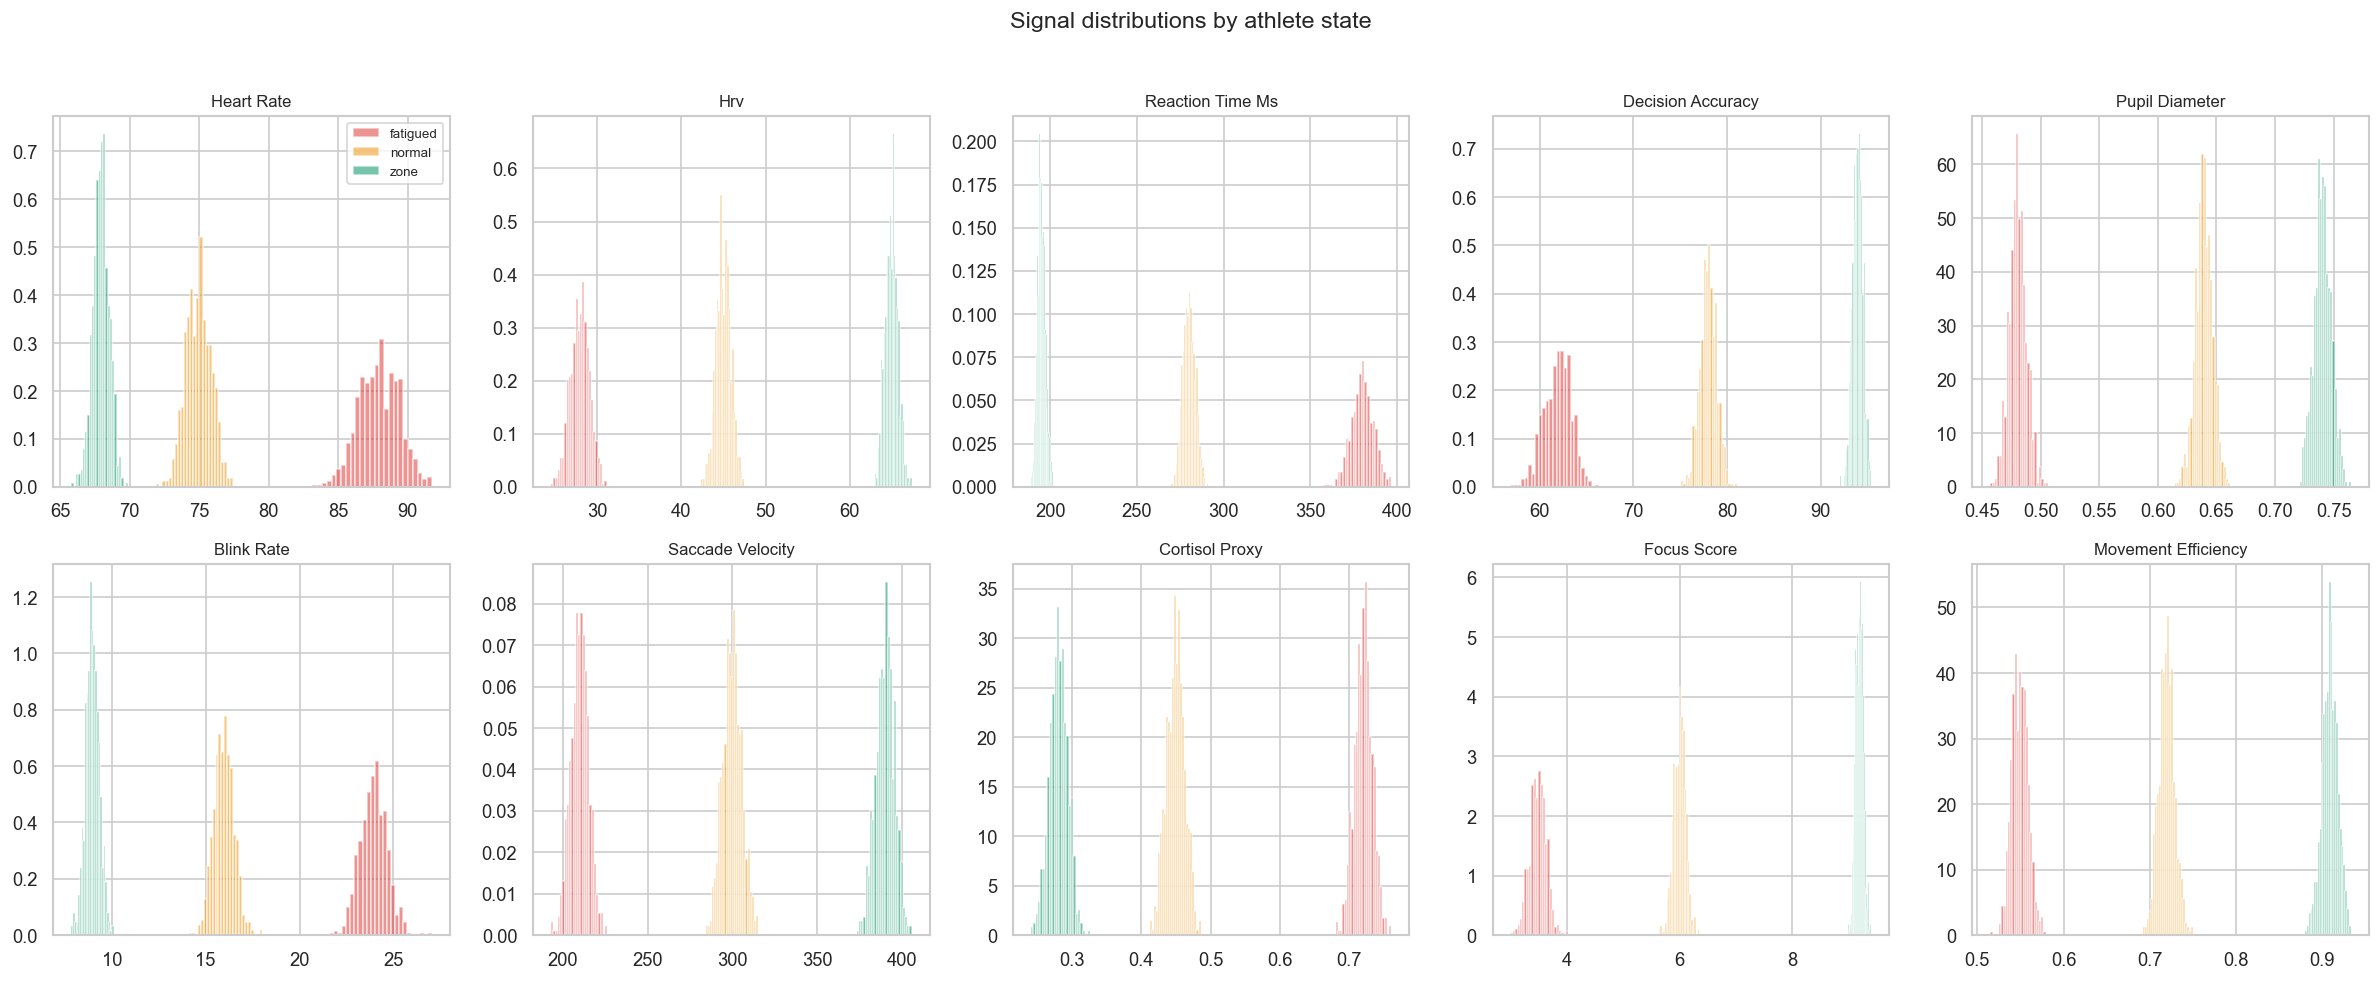

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, signal in enumerate(SIGNALS):
    col = f"{signal}_mean"
    for state, color in COLOR_MAP.items():
        subset = df[df["state_label"]==state][col]
        axes[i].hist(subset, bins=25, alpha=0.6,
                     color=color, label=state, density=True)
    axes[i].set_title(signal.replace("_"," ").title(), fontsize=10)
    axes[i].set_xlabel("")
    if i == 0:
        axes[i].legend(fontsize=8)

plt.suptitle("Signal distributions by athlete state", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../data/distributions.png", bbox_inches="tight")
plt.show()

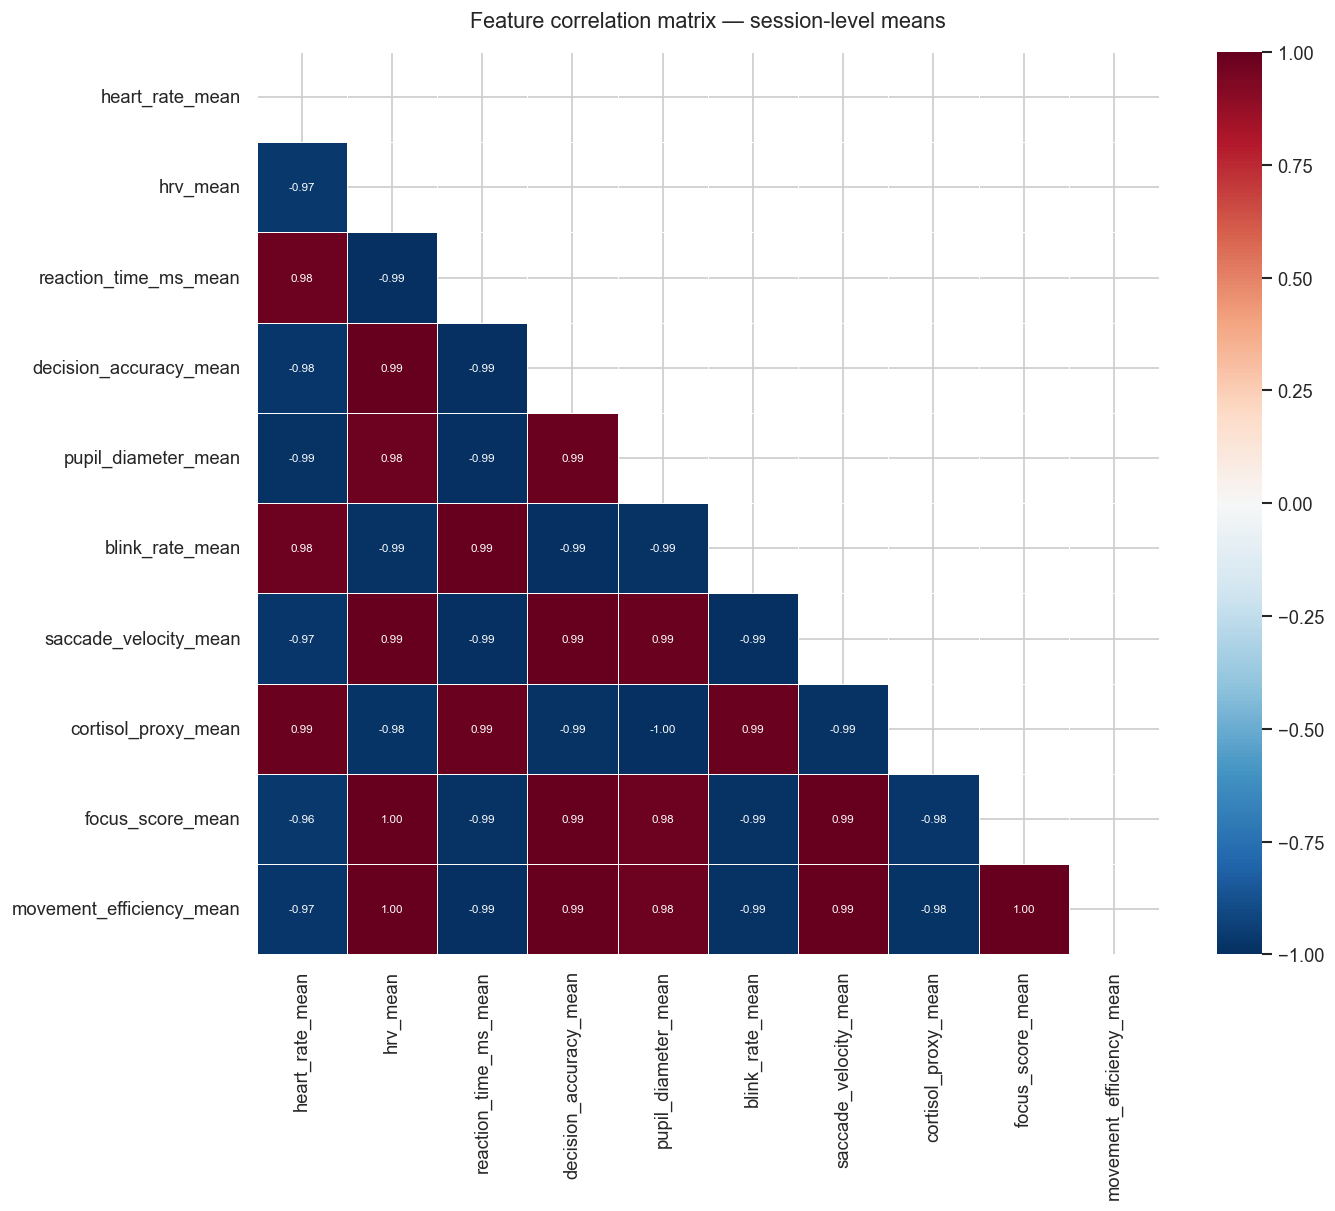

In [4]:
feat_cols = [f"{s}_mean" for s in SIGNALS]
corr = df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="RdBu_r", center=0, square=True,
            linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            annot_kws={"size": 7})
ax.set_title("Feature correlation matrix — session-level means",
             fontsize=13, pad=15)
plt.tight_layout()
plt.savefig("../data/correlation_heatmap.png", bbox_inches="tight")
plt.show()

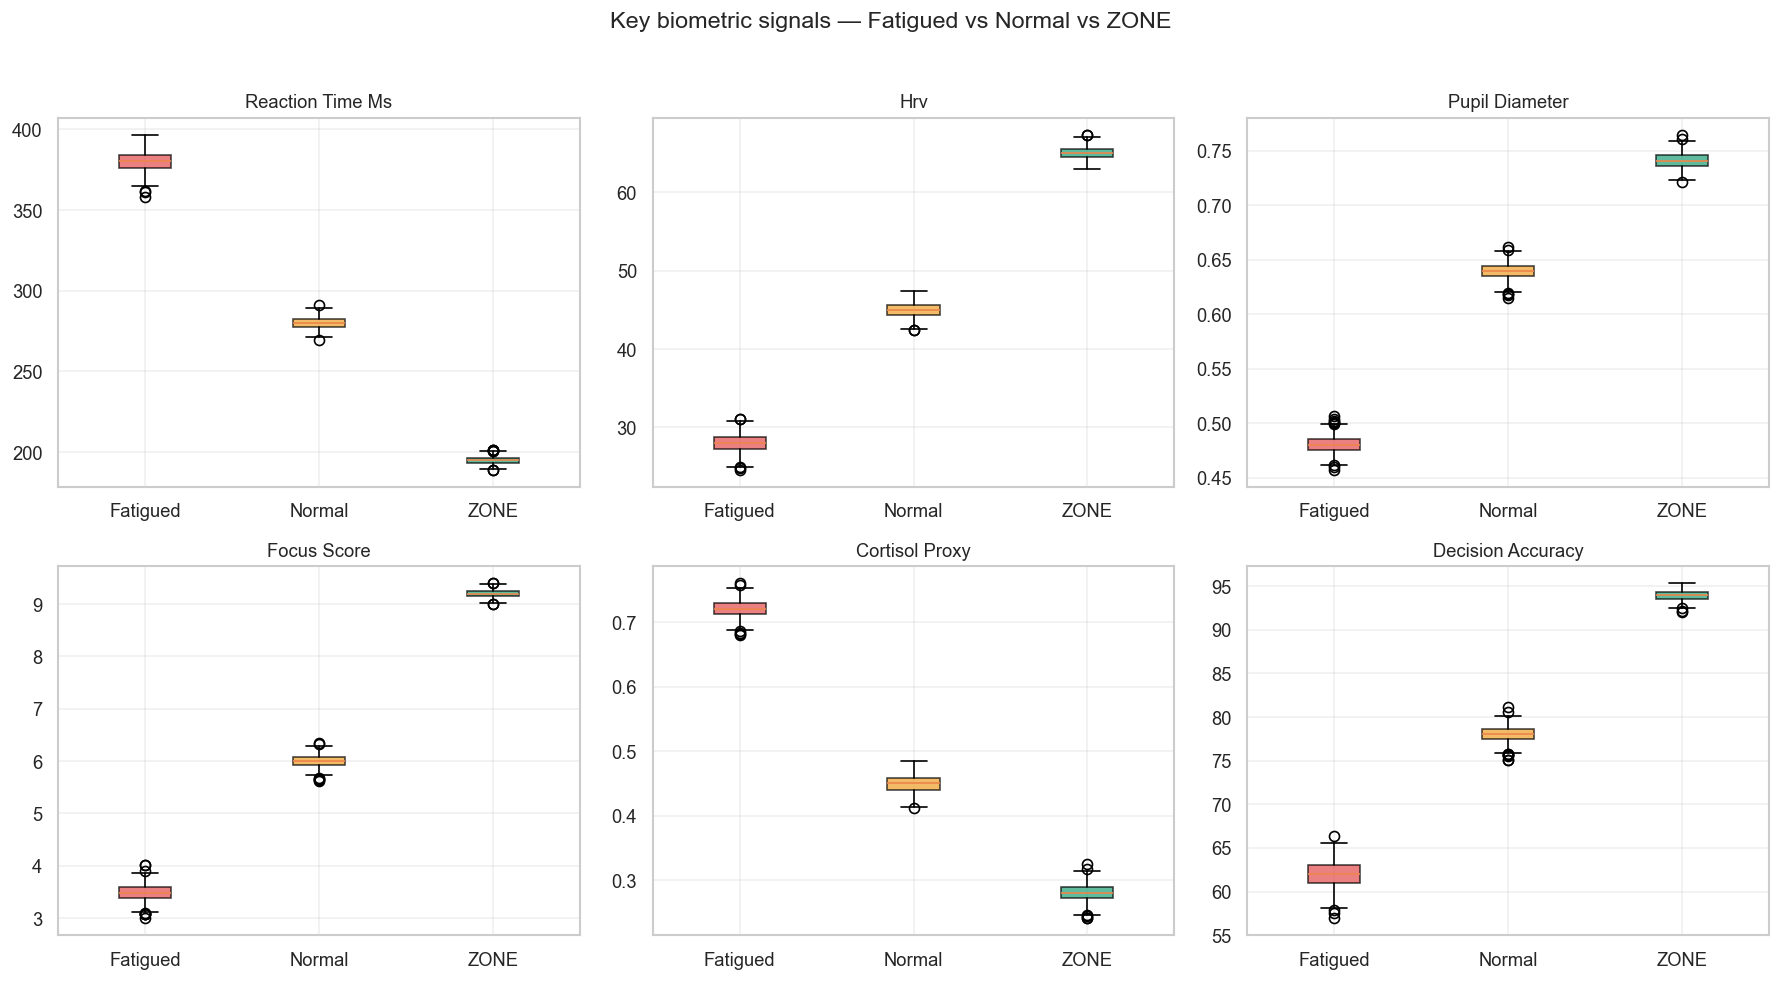

In [5]:
key_signals = ["reaction_time_ms","hrv","pupil_diameter",
               "focus_score","cortisol_proxy","decision_accuracy"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, signal in enumerate(key_signals):
    col = f"{signal}_mean"
    data_by_state = [df[df["state_label"]==s][col].values
                     for s in ["fatigued","normal","zone"]]
    bp = axes[i].boxplot(data_by_state, patch_artist=True,
                          labels=["Fatigued","Normal","ZONE"])
    colors = ["#E24B4A","#EF9F27","#1D9E75"]
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i].set_title(signal.replace("_"," ").title(), fontsize=11)
    axes[i].grid(True, alpha=0.3)

plt.suptitle("Key biometric signals — Fatigued vs Normal vs ZONE",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("../data/boxplots.png", bbox_inches="tight")
plt.show()

In [6]:
sport_zone = df[df["state_label"]=="zone"].groupby("sport").agg(
    zone_sessions=("session_id","count"),
    avg_focus=("focus_score_mean","mean"),
    avg_reaction=("reaction_time_ms_mean","mean")
).round(2)

print("Sport breakdown in ZONE state:")
print(sport_zone.sort_values("avg_focus", ascending=False))

fig = px.bar(sport_zone.reset_index(),
             x="sport", y="avg_focus",
             color="avg_reaction",
             color_continuous_scale="RdYlGn_r",
             title="Average focus score in ZONE state by sport",
             labels={"avg_focus":"Avg focus score",
                     "avg_reaction":"Avg reaction time (ms)"})
fig.show()

Sport breakdown in ZONE state:
            zone_sessions  avg_focus  avg_reaction
sport                                             
basketball            126       9.20        194.85
football              140       9.20        194.80
tennis                 98       9.20        195.22
swimming              126       9.20        194.66
athletics              91       9.19        194.77
cycling               119       9.19        195.14
